In [12]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
from skimage.io import imread
from skimage.color import rgb2gray
from skimage import filters
from skimage import feature
from skimage import morphology
from skimage.feature import match_template


In [2]:
uploaded = files.upload()

nomes = list(uploaded.keys())

imgs = {}

for nome in nomes:
    img = imread(nome)

    if len(img.shape) == 3:
        img = rgb2gray(img)

    imgs[nome] = img


Saving sandalia2_3.jpg to sandalia2_3.jpg
Saving sandalia2_1.jpg to sandalia2_1.jpg
Saving sandalia2_2.jpg to sandalia2_2.jpg
Saving sandalia1_3.jpg to sandalia1_3.jpg
Saving sandalia1_2.jpg to sandalia1_2.jpg
Saving sandalia1_1.jpg to sandalia1_1.jpg
Saving tenis2_3.jpg to tenis2_3.jpg
Saving tenis2_2.jpg to tenis2_2.jpg
Saving tenis2_1.jpg to tenis2_1.jpg
Saving tenis1_3.jpg to tenis1_3.jpg
Saving tenis1_2.jpg to tenis1_2.jpg
Saving tenis1_1.jpg to tenis1_1.jpg


In [9]:
imagens = []
nomes_imagens = list(uploaded.keys())

for nome in nomes_imagens:

    img = imread(nome)

    if len(img.shape) == 3:
        img = rgb2gray(img)

    imagens.append(img)

print(f"{len(imagens)} imagens carregadas com sucesso.")


12 imagens carregadas com sucesso.


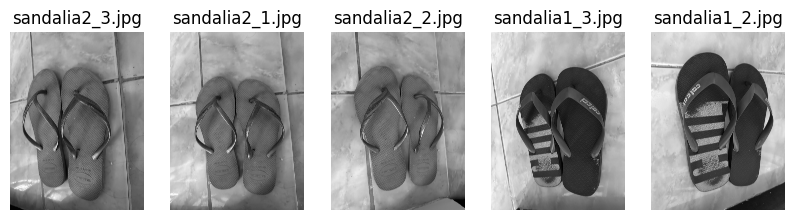

In [10]:
plt.figure(figsize=(10,5))

for i, img in enumerate(imagens[:5]):
    plt.subplot(1, min(5, len(imagens)), i+1)
    plt.imshow(img, cmap='gray')
    plt.title(nomes_imagens[i])
    plt.axis('off')

plt.show()


In [16]:
def preprocessar_para_bordas(img):

    img_suave = filters.gaussian(img, sigma=0.8)

    # Canny
    bordas = feature.canny(
        img_suave,
        sigma=1.2,
        low_threshold=0.05,
        high_threshold=0.15
    )

    # Morfologia
    bordas = morphology.closing(bordas, morphology.disk(1))

    return bordas

In [17]:
bordas_imagens = []

for img in imagens:
    bordas = preprocessar_para_bordas(img)
    bordas_imagens.append(bordas)

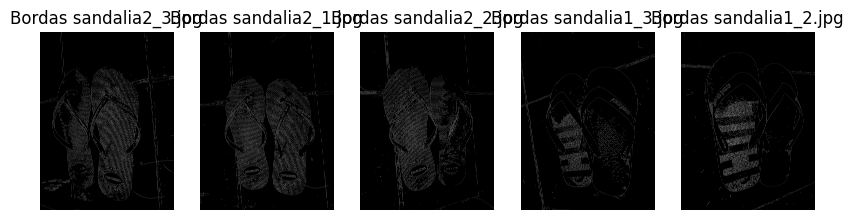

In [18]:
plt.figure(figsize=(10,5))

for i, img in enumerate(bordas_imagens[:5]):
    plt.subplot(1, min(5, len(bordas_imagens)), i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"Bordas {nomes_imagens[i]}")
    plt.axis('off')

plt.show()

(np.float64(-0.5), np.float64(3023.5), np.float64(4031.5), np.float64(-0.5))

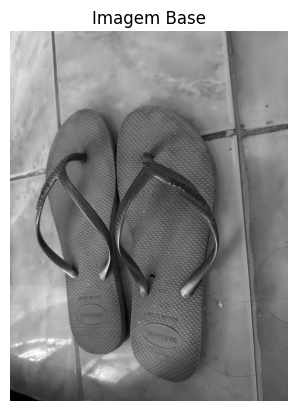

In [19]:
#imagem base
img_base = imagens[0]
bordas_base = bordas_imagens[0]

plt.imshow(img_base, cmap='gray')
plt.title("Imagem Base")
plt.axis('off')


(np.float64(-0.5), np.float64(1299.5), np.float64(1699.5), np.float64(-0.5))

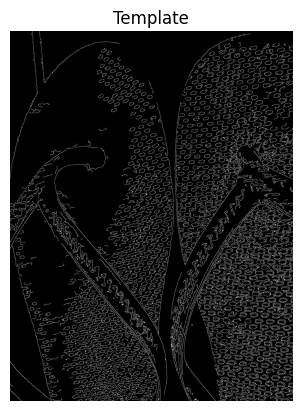

In [20]:
# RECORTE
template = bordas_base[800:2500, 400:1700]

plt.imshow(template, cmap='gray')
plt.title("Template")
plt.axis('off')


In [21]:
# Template Matching
# Correlação
from skimage.feature import match_template

imagem_target = bordas_imagens[1]

result = match_template(imagem_target, template)

In [22]:
# Encontrar Melhor Match
ij = np.unravel_index(np.argmax(result), result.shape)
y, x = ij

h, w = template.shape

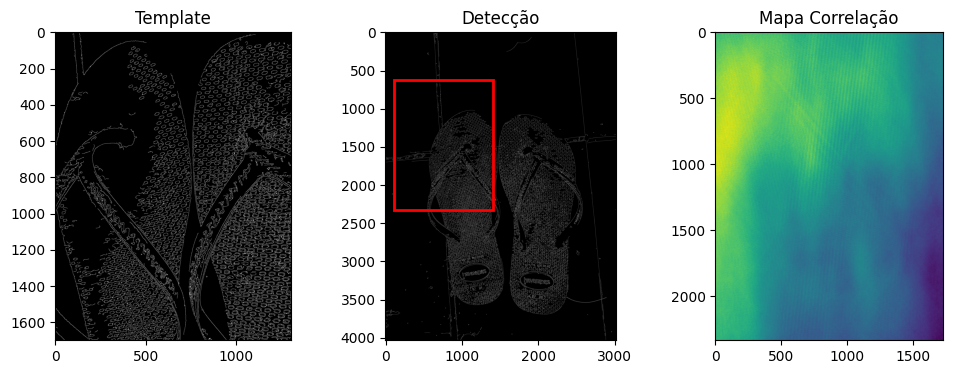

In [23]:
# Visualizar Resultado
plt.figure(figsize=(12,4))

plt.subplot(131)
plt.title("Template")
plt.imshow(template, cmap='gray')

plt.subplot(132)
plt.title("Detecção")
plt.imshow(imagem_target, cmap='gray')

rect = plt.Rectangle((x,y), w, h,
                     edgecolor='red',
                     facecolor='none',
                     linewidth=2)

plt.gca().add_patch(rect)

plt.subplot(133)
plt.title("Mapa Correlação")
plt.imshow(result, cmap='viridis')

plt.show()

In [24]:
# melhoria

from skimage.feature import canny
bordas = canny(img, sigma=2)

In [25]:
template = bordas_base[900:1800, 600:1200]

In [26]:
# Normalizar template
template = template.astype(float)
template = (template - template.mean()) / (template.std() + 1e-6)

In [27]:
from skimage.feature import match_template
import matplotlib.pyplot as plt
import numpy as np


img_busca = bordas_imagens[8]


resultado = match_template(img_busca, template)

ij = np.unravel_index(np.argmax(resultado), resultado.shape)
y, x = ij


h, w = template.shape

print("Pico de correlação em:", (y, x))
print("Valor máximo:", resultado[y, x])


Pico de correlação em: (np.int64(2177), np.int64(1066))
Valor máximo: 0.03638345103489547


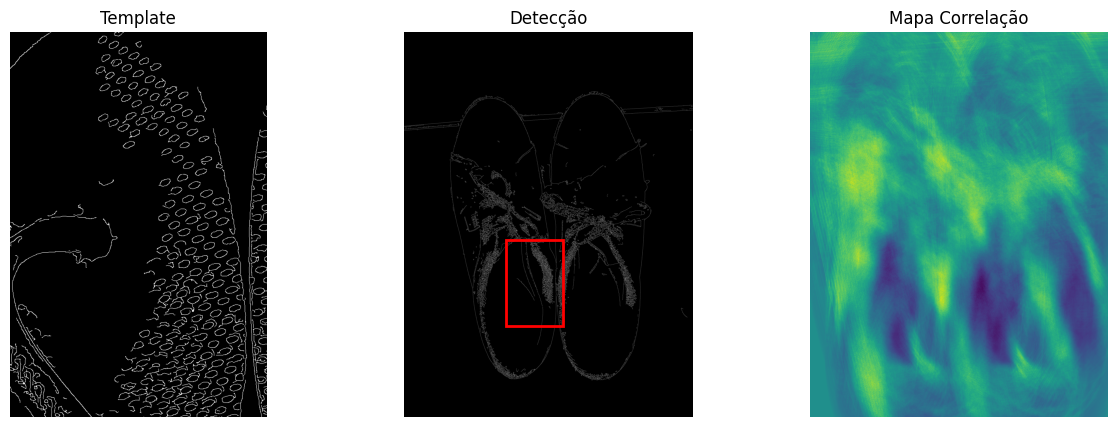

In [28]:
fig, ax = plt.subplots(1, 3, figsize=(15,5))

# Template
ax[0].imshow(template, cmap='gray')
ax[0].set_title("Template")

# Detecção
ax[1].imshow(img_busca, cmap='gray')
rect = plt.Rectangle((x, y), w, h, edgecolor='red', facecolor='none', linewidth=2)
ax[1].add_patch(rect)
ax[1].set_title("Detecção")

# Mapa correlação
ax[2].imshow(resultado, cmap='viridis')
ax[2].set_title("Mapa Correlação")

for a in ax:
    a.axis("off")

plt.show()